### Torch model from scratch
start with simple MLP. possibly start with all their data prep methods so can reuse the custom fire dataset i wrote in the other file. may end up rewriting the data prep methods because i don't like that they have hardcoded values but we'll come back to that

actual network layers: two schools of thought
1- create sequential blocks to group layers together, run input through all the layers by just calling the block
2 - create layers individually then pass input individually in forward method. may be easier to debug later?

For an MLP, input needs to be flattened into a 1D tensor. our data files are loaded in from the csv files as 1D images, but are still 12-channels so still need to flatten.
sizes: if using 64x64, size = 12x64x64 = 49152. if using 32x32, size = 12x32x32 = 12288

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from typing import Tuple, List
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import numpy as np




In [4]:
import torchvision.transforms as transforms
"""
Data crop methods
Changes made:
- replaced tf.Tensor with torch.tensor in headers
- torch.cat
- replaced tf.image.random_crop with a RandomCrop transform 
- replaced tf.image.central_crop with a CentralCrop transform

"""


"""Randomly axis-align crop input and output image tensors.

Args:
    crop_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    desired_size: side length (square) to crop to.
    num_in_channels: number of channels in crop_img.
    num_out_channels: number of channels in output_img.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def random_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int, num_in_channels: int, num_out_channels: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order should be CWH (no batch dim yet!!)
    # concat first (over CHANNELS, axis=1) so that image and label will be cropped the same, then separate again
    combined = torch.cat([input_img, output_img], dim=0) # CHW ordering (channel = dim0) rather than HWC as in tf. dim same as axis
    cropTransform = transforms.RandomCrop(size=(desired_size, desired_size))
    combined = cropTransform(combined)
    
    # size CHW (channel first)
    input_img = combined[0:num_in_channels, :, :]
    output_img = combined[-num_out_channels:, :, :]

    return input_img, output_img

"""Center crops input and output image tensors.

Args:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    sample_size: side length (square) to crop to.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def center_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order is CHW not HWC as in torch so 0=channel, 1=height, 2=width
    central_fraction = desired_size / input_img.shape[1]
    cropH = int(input_img.shape[1]*central_fraction)
    cropW = int(input_img.shape[2]*central_fraction)

    cropTransform = transforms.CenterCrop(size=(cropH, cropW))
    input_img = cropTransform(input_img)
    output_img = cropTransform(output_img)

    return input_img, output_img


"""Clips and normalizes inputs with the stats corresponding to `key`.
Args:
    inputs: Inputs to clip and normalize.
    key: Key describing the inputs.

Returns:
    Clipped and normalized input.
"""
def clip_and_normalize(feature_name:str, inputs:torch.Tensor):
    min_val, max_val, mean, std = DATA_STATS[feature_name]
    inputs = torch.clamp(inputs, min=min_val, max=max_val) # clip to specified range

    # explicitly convert tuples to tensors and specify device/type so no match errors happen
    mean = torch.as_tensor(mean, device=inputs.device, dtype=inputs.dtype)
    std = torch.as_tensor(std, device=inputs.device, dtype=inputs.dtype)

    inputs = (inputs - mean)/std
    inputs = torch.nan_to_num(inputs, nan=0.0)

    return inputs


"""Clips and rescales inputs with the stats corresponding to `key`.
Args:
    inputs: Inputs to clip and rescale.
    feature_name: Key describing the inputs.

Returns:
    Clipped and rescaled input.
"""
def clip_and_rescale(feature_name:str, inputs:torch.Tensor):
    min_val, max_val, _, _ = DATA_STATS[feature_name]
    inputs = torch.clamp(inputs, min=min_val, max=max_val,)
    inputs = (inputs - min_val)/(max_val - min_val)
    inputs = torch.nan_to_num(inputs, nan=0.0)

    return inputs

In [5]:
"""Constants for the data reader."""

INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']

OUTPUT_FEATURES = ['FireMask', ]

# Data statistics 
# For each variable, the statistics are ordered in the form:
# (min_clip, max_clip, mean, standard deviation)
DATA_STATS = {
    # Elevation in m.
    # 0.1 percentile, 99.9 percentile
    'elevation': (0.0, 3141.0, 657.3003, 649.0147),
    # Pressure
    # 0.1 percentile, 99.9 percentile
    'pdsi': (-6.12974870967865, 7.876040384292651, -0.0052714925, 2.6823447),
    'NDVI': (-9821.0, 9996.0, 5157.625, 2466.6677),  # min, max
    # Precipitation in mm.
    # Negative values do not make sense, so min is set to 0.
    # 0., 99.9 percentile
    'pr': (0.0, 44.53038024902344, 1.7398051, 4.482833),
    # Specific humidity.
    # Negative values do not make sense, so min is set to 0.
    # The range of specific humidity is up to 100% so max is 1.
    'sph': (0., 1., 0.0071658953, 0.0042835088),
    # Wind direction in degrees clockwise from north.
    # Thus min set to 0 and max set to 360.
    'th': (0., 360.0, 190.32976, 72.59854),
    # Min/max temperature in Kelvin.
    # -20 degree C, 99.9 percentile
    'tmmn': (253.15, 298.94891357421875, 281.08768, 8.982386),
    # -20 degree C, 99.9 percentile
    'tmmx': (253.15, 315.09228515625, 295.17383, 9.815496),
    # Wind speed in m/s.
    # Negative values do not make sense, given there is a wind direction.
    # 0., 99.9 percentile
    'vs': (0.0, 10.024310074806237, 3.8500874, 1.4109988),
    # NFDRS fire danger index energy release component expressed in BTU's per
    # square foot.
    # Negative values do not make sense. Thus min set to zero.
    # 0., 99.9 percentile
    'erc': (0.0, 106.24891662597656, 37.326267, 20.846027),
    # Population density
    # min, 99.9 percentile
    'population': (0., 2534.06298828125, 25.531384, 154.72331),
    # We don't want to normalize the FireMasks.
    # 1 indicates fire, 0 no fire, -1 unlabeled data
    'PrevFireMask': (-1., 1., 0., 1.),
    'FireMask': (-1., 1., 0., 1.)
}

In [6]:
class FireDataset(Dataset):

    def __init__(self, file_paths:List[str], data_size=64, crop_size=32, in_channels=12, 
                 clip_and_norm=True, clip_and_rescale=False, 
                 random_crop=True, center_crop=False):
        
        self.file_paths = file_paths
        self.center_crop = center_crop
        self.random_crop = random_crop
        self.clip_and_norm = clip_and_norm
        self.clip_and_rescale = clip_and_rescale
        self.data_size = data_size
        self.crop_size = crop_size
        self.in_channels = in_channels

        # read in all samples at once: leave preprocessing to getitem() method
        self.in_images = []
        self.labels = []
        self.base_dir = "C:\\Users\\rball\\OneDrive\\Documents\\school\\00 GRADUATE\\Thesis\\03DataVisualization\\mid-process-data-files\\csv-files\\"
        for file in self.file_paths:
            curr_file = self.base_dir + file
            df = pd.read_csv(curr_file)

            # can't just select the first column since they are not always in order
            target = df["FireMask"].astype(np.float32)
            target = target.values.reshape(64, 64, 1)

            data = df.drop('FireMask', axis=1).astype(np.float32)
            data = data[INPUT_FEATURES] # sort features into consistent order
            data = data.values.reshape(64, 64, 12)
            
            # permute to get in shape CHW. DONT unsqueeze for batch dim as that is added by DataLoader!!!!
            image = torch.tensor(data, dtype=torch.float32).permute(2,0,1)
            self.in_images.append(image)

            label = torch.tensor(target, dtype=torch.float32).permute(2,0,1)
            self.labels.append(label)
 
   
    def __len__(self):
        return len(self.file_paths)
    

    def __getitem__(self, idx): # GETITEM RETURNS WITH SIZE CHW
        # in_images is already a list of tensors in the correct shape
        input_img = self.in_images[idx]
        output_img = self.labels[idx]

        if self.random_crop and self.center_crop:
            raise ValueError('Cannot have both random_crop and center_crop be True')

        if self.clip_and_norm:
            transformed = []
            for feature, channel in zip(INPUT_FEATURES, input_img.unbind(dim=0)):
                transformed.append(clip_and_normalize(feature, channel))
            input_img = torch.stack(transformed)
        elif self.clip_and_rescale:
            transformed = []
            for feature, channel in zip(INPUT_FEATURES, input_img.unbind(dim=0)):
                transformed.append(clip_and_rescale(feature, channel))
            input_img = torch.stack(transformed)

        if self.random_crop:
            input_img, output_img = random_crop_io(input_img, output_img, desired_size=self.crop_size, 
                                        num_in_channels=self.in_channels, num_out_channels=1)
        elif self.center_crop:
            input_img, output_img = center_crop_io(input_img, output_img, desired_size=self.crop_size)
            
        #print("input shape:", input_img.shape, " output shape:", output_img.shape )
        return input_img, output_img
        

test_file_paths = ["test_00.csv", "test_01.csv"]
eval_file_paths = ["eval_00.csv", "eval_01.csv"]
train_file_paths = ["train_00.csv", "train_01.csv", "train_02.csv", "train_03.csv", "train_04.csv", 
                    "train_05.csv", "train_06.csv", "train_07.csv", "train_08.csv", "train_09.csv", 
                    "train_10.csv", "train_11.csv", "train_12.csv", "train_13.csv", "train_14.csv"]

test_dataset = FireDataset(test_file_paths, clip_and_norm=False, clip_and_rescale=True)
eval_dataset = FireDataset(eval_file_paths, clip_and_norm=False, clip_and_rescale=True)
train_dataset = FireDataset(train_file_paths, clip_and_norm=False, clip_and_rescale=True)

# eval just needs one sample for validation???
BATCH_SIZE=32
eval_dataloader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)



#print(data)

In [7]:
import matplotlib.pyplot as plt

def show_32x32(img, title):
    """
    img: torch.Tensor or numpy array of shape (32, 32)
         values assumed in [0, 1]
    """
    # normalize to [0, 1]
    #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img, cmap="gray_r")  # gray_r flips: 1=black, 0=white
    plt.title(title)
    plt.axis('off')
    plt.show()


### weights
weights for nn.Linear are initialized from U(-sqrt(k), sqrt(k)) where k = 1/in_features and U  
is a uniform distribution  

weights for mobilenetv2(weights=None) are whatever is normal for conv layers, which is Kaiming/He normal initalization  

can use torch.nn.init weight initialization methods:  
to try with kaiming distro, try torch.nn.init.kaiming_uniform_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu', generator=None)

torch.Size([2, 12, 32, 32])
max/min after flatten:  tensor(1.) tensor(0.)
max/min after linear1:  tensor(2.5934, grad_fn=<MaxBackward1>) tensor(-2.4880, grad_fn=<MinBackward1>)
max after relu1:        tensor(1.0000, grad_fn=<MaxBackward1>) tensor(0., grad_fn=<MinBackward1>)
          zeros:        2000
         x size:        torch.Size([2, 2000])
max/min after linear2:  tensor(1.2715, grad_fn=<MaxBackward1>) tensor(-1.5136, grad_fn=<MinBackward1>)
max after relu2:        tensor(1.0000, grad_fn=<MaxBackward1>) tensor(0., grad_fn=<MinBackward1>)
          zeros:        2000
         x size:        torch.Size([2, 2000])
max/min after linear3:  tensor(1.4180, grad_fn=<MaxBackward1>) tensor(-1.5642, grad_fn=<MinBackward1>)
max after relu3:        tensor(1.0000, grad_fn=<MaxBackward1>) tensor(0., grad_fn=<MinBackward1>)
          zeros:        2000
         x size:        torch.Size([2, 2000])
max/min after linear4:  tensor(1.4822, grad_fn=<MaxBackward1>) tensor(-1.3486, grad_fn=<MinBackwar

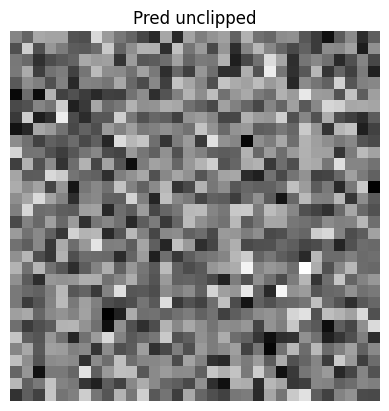

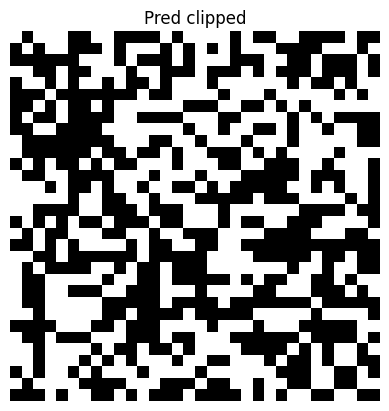

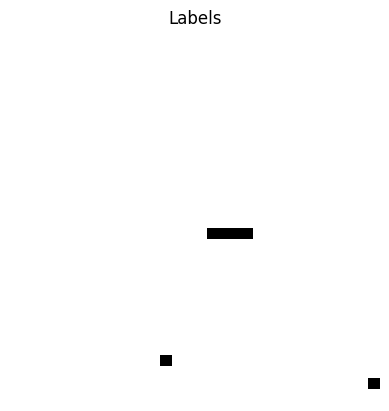

In [8]:
hw_size = 32 # start by assuming input is 32x32 after crop
c_size = 12

class CAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__() # calling/initializing the nn Module

        #assuming right now that input will be passed as B, 12, 32, 32
        self.flatten = nn.Flatten(start_dim=1)

        # pick some arbitrary size for inner layers, say 2000 just for funsies
        # output needs to be 32*32 = 1024 spatial size for an image
        self.linear1 = nn.Linear(in_features=(hw_size*hw_size*c_size), out_features=2000)
        # changing weight initialization
        nn.init.kaiming_uniform_(self.linear1.weight, nonlinearity='relu')

        self.bn1 = nn.BatchNorm1d(num_features=2000)
        self.relu1 = nn.ReLU()

        self.linear2 = nn.Linear(2000,2000)
        self.bn2 = nn.BatchNorm1d(num_features=2000)
        self.relu2 = nn.ReLU()

        self.linear3 = nn.Linear(2000,2000)
        self.bn3 = nn.BatchNorm1d(num_features=2000)
        self.relu3 = nn.ReLU()

        self.linear4 = nn.Linear(2000, hw_size*hw_size)
        self.sigmoid = nn.Sigmoid()
        # self.bn4 = nn.BatchNorm1d(num_features=hw_size*hw_size)
        # self.lastRelu = nn.ReLU()

        # unflatten
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(1, 32, 32))

    def forward(self, x):
        x = self.flatten(x)
        print("max/min after flatten: ", x.max(), x.min())

        x = self.linear1(x)
        print("max/min after linear1: ", x.max(), x.min())
        x = self.bn1(x)
        x = self.relu1(x)
        zcount = torch.sum(x==0).item()
        print("max after relu1:       ", x.max(), x.min())
        print("          zeros:       ", zcount)
        print("         x size:       ", x.shape)

        x = self.linear2(x)
        print("max/min after linear2: ", x.max(), x.min())
        x = self.bn2(x)
        x = self.relu2(x)
        zcount = torch.sum(x==0).item()
        print("max after relu2:       ", x.max(), x.min())
        print("          zeros:       ", zcount)
        print("         x size:       ", x.shape)

        x = self.linear3(x)
        print("max/min after linear3: ", x.max(), x.min())
        x = self.bn3(x)
        x = self.relu3(x)
        zcount = torch.sum(x==0).item()
        print("max after relu3:       ", x.max(), x.min())
        print("          zeros:       ", zcount)
        print("         x size:       ", x.shape)

        x = self.linear4(x)
        print("max/min after linear4: ", x.max(), x.min())
        # x = self.bn4(x)
        # x = self.lastRelu(x)
        x = self.sigmoid(x)
        zcount = torch.sum(x==0).item()
        print("max after sigmoid:     ", x.max(), x.min())
        print("            zeros:     ", zcount)
        print("           x size:     ", x.shape)

        # unflatten
        x = self.unflatten(x)
 
        return x
    

inputs, labels = next(iter(test_loader))
print(inputs.shape)
model = CAutoEncoder()
test_out = model(inputs)
out_clip = (test_out>=0.5).int()
print(test_out.shape)
print("max: ", test_out.max(), "\nmin: ", test_out.min())
#print(out_clip.shape)
show_32x32(test_out.detach().numpy()[0,0,:,:], "Pred unclipped")
show_32x32(out_clip.detach().numpy()[0,0,:,:], "Pred clipped")
show_32x32(labels[0,0,:,:], "Labels")


In [ ]:
loss = 